In [1]:
#import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
#cwd = os.getcwd()

In [2]:
df=pd.read_excel("C:/Users/bazra/Desktop/Projet RED/CIV/Consultation_2022_A2.xlsx")

In [3]:
df.head()

,Unnamed: 0,s01q01,s00q04,s02q29,s03q01,s03q05,s03q06,s03q07
0,0,Masculin,Urbain,Secondaire 1 (Post Primaire) Général,Oui,Oui,NaN,CHU
1,1,Féminin,Urbain,NaN,Non,NaN,NaN,NaN
2,2,Féminin,Urbain,Secondaire 2 Général,Non,NaN,NaN,NaN
3,3,Féminin,Urbain,NaN,Non,NaN,NaN,NaN
4,4,Féminin,Urbain,NaN,Non,NaN,NaN,NaN


In [4]:
df['s01q01'].value_counts()

s01q01
Féminin     32830
Masculin    31661
Name: count, dtype: int64

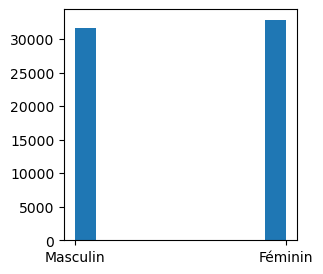

In [9]:
#Making a histogram of gender variable
plt.figure(figsize=(3,3))
plt.hist(df['s01q01'])
plt.show()

In [3]:
dfr = df.rename(columns= {'s01q01': 'Sexe', 's00q04': 'Milieu de résidence','s02q29': 'Niveau études', 's03q01': 'Problème santé au cours des 30 derniers jours sans hospitalisation', 
    's03q05': 'Consultation', 's03q06': 'Raison non consultation', 's03q07': 'Lieu consultation' })

In [11]:
dfr.head()

,Unnamed: 0,Sexe,Milieu de résidence,Niveau études,Problème santé au cours des 30 derniers jours sans hospitalisation,Consultation,Raison non consultation,Lieu consultation
0,0,Masculin,Urbain,Secondaire 1 (Post Primaire) Général,Oui,Oui,NaN,CHU
1,1,Féminin,Urbain,NaN,Non,NaN,NaN,NaN
2,2,Féminin,Urbain,Secondaire 2 Général,Non,NaN,NaN,NaN
3,3,Féminin,Urbain,NaN,Non,NaN,NaN,NaN
4,4,Féminin,Urbain,NaN,Non,NaN,NaN,NaN


In [25]:
dfr['Milieu de résidence'].value_counts()

Milieu de résidence
Rural     39318
Urbain    25173
Name: count, dtype: int64

In [13]:
dfr.describe(include="all")

,Unnamed: 0,Sexe,Milieu de résidence,Niveau études,Problème santé au cours des 30 derniers jours sans hospitalisation,Consultation,Raison non consultation,Lieu consultation
count,64491.000000,64491,64491,13012,64491,17220,6203,11017
unique,NaN,2,2,8,2,2,13,13
top,NaN,Féminin,Rural,Primaire,Non,Oui,Automédication,centre de santé rural/dispensaire rural
freq,NaN,32830,39318,7032,47271,11017,3451,3762
mean,32245.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,18617.092442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,16122.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,32245.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,48367.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
dfr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64491 entries, 0 to 64490
Data columns (total 8 columns):
 #   Column                                                              Non-Null Count  Dtype 
---  ------                                                              --------------  ----- 
 0   Unnamed: 0                                                          64491 non-null  int64 
 1   Sexe                                                                64491 non-null  object
 2   Milieu de résidence                                                 64491 non-null  object
 3   Niveau études                                                       13012 non-null  object
 4   Problème santé au cours des 30 derniers jours sans hospitalisation  64491 non-null  object
 5   Consultation                                                        17220 non-null  object
 6   Raison non consultation                                             6203 non-null   object
 7   Lieu consultation      

In [15]:
dfr.isna().sum()


Unnamed: 0                                                                0
Sexe                                                                      0
Milieu de résidence                                                       0
Niveau études                                                         51479
Problème santé au cours des 30 derniers jours sans hospitalisation        0
Consultation                                                          47271
Raison non consultation                                               58288
Lieu consultation                                                     53474
dtype: int64

In [16]:
dfr.duplicated().sum()

np.int64(0)

In [5]:
tableau = pd.pivot_table(
    dfr,
    index="Sexe",
    columns="Consultation",
    aggfunc="sum"
)

In [6]:
print(tableau)

             Lieu consultation  \
Consultation               Non   
Sexe                             
Féminin                      0   
Masculin                     0   

                                                                 \
Consultation                                                Oui   
Sexe                                                              
Féminin       Autre publicHôpital GénéralCentre de santé urb...   
Masculin      CHUHôpital GénéralAutre publicClinique d'entre...   

                                            Milieu de résidence  \
Consultation                                                Non   
Sexe                                                              
Féminin       UrbainUrbainUrbainUrbainUrbainUrbainUrbainUrba...   
Masculin      UrbainUrbainUrbainUrbainUrbainUrbainUrbainUrba...   

                                                                 \
Consultation                                                Oui   
Sexe                   

In [4]:
tableau2 = pd.pivot_table(
    dfr,
    index="Sexe",
    columns="Raison non consultation",
    aggfunc="sum"
)*100

In [6]:
print(tableau2)

                                                              Consultation  \
Raison non consultation                               Absence de personnel   
Sexe                                                                         
Féminin                                                                NaN   
Masculin                 NonNonNonNonNonNonNonNonNonNonNonNonNonNonNonN...   

                                                                            \
Raison non consultation                             Attente de rendez-vous   
Sexe                                                                         
Féminin                  NonNonNonNonNonNonNonNonNonNonNonNonNonNonNonN...   
Masculin                 NonNonNonNonNonNonNonNonNonNonNonNonNonNonNonN...   

                                                                            \
Raison non consultation                                     Automédication   
Sexe                                                          

In [7]:
table_pct_ligne = pd.crosstab(
    dfr['Sexe'],
    dfr['Raison non consultation'],
    normalize='index'
) * 100

In [9]:
print(table_pct_ligne)

Raison non consultation  Absence de personnel  Attente de rendez-vous  \
Sexe                                                                    
Féminin                              0.000000                0.277864   
Masculin                             0.101215                0.202429   

Raison non consultation  Automédication  Autre à préciser  Manque d'argent  \
Sexe                                                                         
Féminin                       54.986107          0.185242        25.316456   
Masculin                      56.342780          0.337382        23.380567   

Raison non consultation  Non satisfait à la dernière consultation  \
Sexe                                                                
Féminin                                                  0.339611   
Masculin                                                 0.202429   

Raison non consultation  Pas de confiance  Pas nécessaire  \
Sexe                                                    

In [10]:
table_pct_ligne_MR = pd.crosstab(
    dfr['Milieu de résidence'],
    dfr['Raison non consultation'],
    normalize='index'
) * 100

In [11]:
print(table_pct_ligne_MR)

Raison non consultation  Absence de personnel  Attente de rendez-vous  \
Milieu de résidence                                                     
Rural                                0.078823                0.183920   
Urbain                               0.000000                0.333751   

Raison non consultation  Automédication  Autre à préciser  Manque d'argent  \
Milieu de résidence                                                          
Rural                         55.123489          0.183920        25.643720   
Urbain                        56.445557          0.375469        22.403004   

Raison non consultation  Non satisfait à la dernière consultation  \
Milieu de résidence                                                 
Rural                                                    0.262743   
Urbain                                                   0.292032   

Raison non consultation  Pas de confiance  Pas nécessaire  \
Milieu de résidence                                     